DATASET LOADED SUCCESSFULLY

First Five Rows
                           ID  \
29795  ID_TR_Swa_Ken_572D3274   
29796  ID_TR_Swa_Ken_5B15674D   
29797  ID_TR_Swa_Ken_0D5348D1   
29798  ID_TR_Swa_Ken_D140F967   
29799  ID_TR_Swa_Ken_6E06F176   
29800  ID_TR_Swa_Ken_8252CAFF   
29801  ID_TR_Swa_Ken_8CDFE58D   
29802  ID_TR_Swa_Ken_2EF38ED1   
29803  ID_TR_Swa_Ken_6FAD7460   
29804  ID_TR_Swa_Ken_92714FEA   
29805  ID_TR_Swa_Ken_1BD8978E   
29806  ID_TR_Swa_Ken_7C4243C7   
29807  ID_TR_Swa_Ken_A05A53C4   
29808  ID_TR_Swa_Ken_D8F148FB   
29809  ID_TR_Swa_Ken_7C3AAA22   
29810  ID_TR_Swa_Ken_6CAA4C8D   
29811  ID_TR_Swa_Ken_C3575FF1   
29812  ID_TR_Swa_Ken_8FB6002D   
29813  ID_TR_Swa_Ken_A4E71358   
29814  ID_TR_Swa_Ken_E704DB7D   

                                                   input  \
29795                           Nikibakwa, nifanye nini?   
29796            Je, PrEP huzuia vipi virusi vya ukimwi?   
29797  Je, mtu aliye na Ukimwi anaweza kuenea kwa wen...   
29798  Je, maambukizi

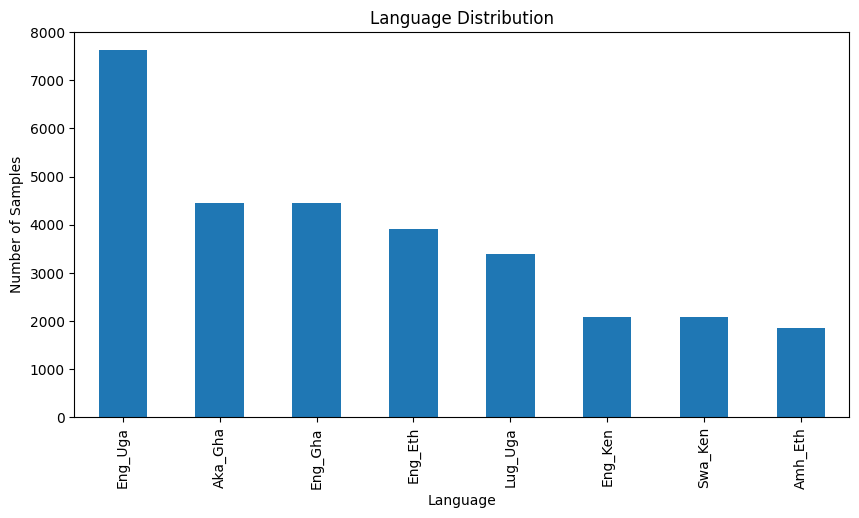


Input Text Length Statistics
count    29815.000000
mean        89.915143
std         50.838964
min          1.000000
25%         55.000000
50%         78.000000
75%        111.000000
max        520.000000
Name: input_length, dtype: float64


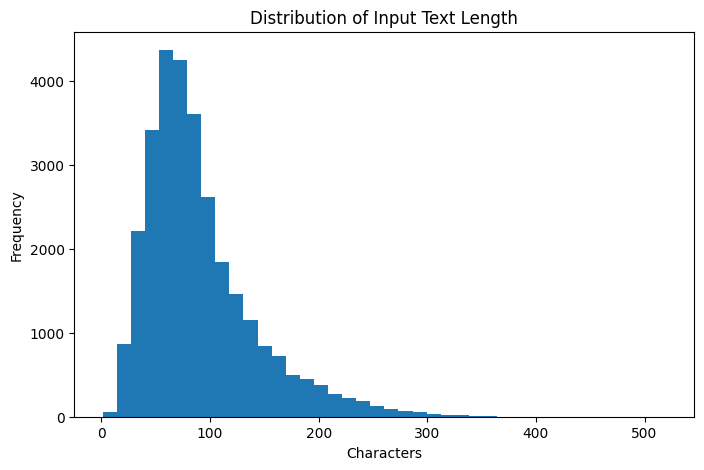

WEEK 1 COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# WEEK 1: DATASET UNDERSTANDING AND EXPLORATORY DATA ANALYSIS
# ============================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

# Load Dataset
df = pd.read_csv("/content/drive/MyDrive/Train llm.csv")

print("="*60)
print("DATASET LOADED SUCCESSFULLY")
print("="*60)

# First five rows
print("\nFirst Five Rows")
print(df.tail(20))

# Dataset Information
print("\nDataset Information")
print(df.info())

# Dataset Shape
print("\nDataset Shape")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# Column Names
print("\nColumn Names")
print(df.columns.tolist())

# Dataset Statistics
print("\nDataset Statistics")
print(df.describe(include='all'))

# Missing Values
print("\nMissing Values")
print(df.isnull().sum())

# Duplicate Records
print("\nDuplicate Records")
print(df.duplicated().sum())

# Random Samples
print("\nRandom Samples")
print(df.sample(5))

# Language Distribution
print("\nLanguage Distribution")
print(df['subset'].value_counts())

# Plot Language Distribution
plt.figure(figsize=(10,5))
df['subset'].value_counts().plot(kind='bar')
plt.title("Language Distribution")
plt.xlabel("Language")
plt.ylabel("Number of Samples")
plt.show()

# Text Length Analysis
df['input_length'] = df['input'].astype(str).str.len()

print("\nInput Text Length Statistics")
print(df['input_length'].describe())

# Histogram
plt.figure(figsize=(8,5))
plt.hist(df['input_length'], bins=40)
plt.title("Distribution of Input Text Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

print("="*60)
print("WEEK 1 COMPLETED SUCCESSFULLY")
print("="*60)

In [ ]:
# ============================================================
# WEEK 2: DATA CLEANING AND PREPROCESSING
# ============================================================

import pandas as pd
import re
from sklearn.model_selection import train_test_split

# Load Dataset
df = pd.read_csv("/content/drive/MyDrive/Train llm.csv")

print("="*60)
print("STARTING DATA PREPROCESSING")
print("="*60)

# Missing Values Before Cleaning
print("\nMissing Values Before Cleaning")
print(df.isnull().sum())

# Remove Missing Values
df = df.dropna()

# Remove Duplicate Records
duplicates_before = df.duplicated().sum()
df = df.drop_duplicates()

print("\nDuplicate Records Removed:", duplicates_before)

# Text Cleaning Function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\\S+', '', text)
    text = re.sub(r'[^a-zA-ZÀ-ÿ\\s]', '', text)
    text = text.strip()
    return text

# Clean Input and Output Columns
df['input'] = df['input'].astype(str).apply(clean_text)
df['output'] = df['output'].astype(str).apply(clean_text)

# Tokenization
df['input_tokens'] = df['input'].apply(lambda x: x.split())
df['output_tokens'] = df['output'].apply(lambda x: x.split())

print("\nTokenization Completed.")

# Split Dataset
train_df, valid_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42
)

print("\nTraining Dataset Shape :", train_df.shape)
print("Validation Dataset Shape :", valid_df.shape)

print("\nTraining Samples")
print(train_df.head())

print("\nValidation Samples")
print(valid_df.head())

print("="*60)
print("WEEK 2 COMPLETED SUCCESSFULLY")
print("="*60)

STARTING DATA PREPROCESSING

Missing Values Before Cleaning
ID        0
input     0
output    0
subset    0
dtype: int64

Duplicate Records Removed: 0

Tokenization Completed.

Training Dataset Shape : (23852, 6)
Validation Dataset Shape : (5963, 6)

Training Samples
                           ID  \
7964   ID_TR_Eng_Eth_B9644E4F   
21760  ID_TR_Eng_Uga_731DC76F   
6757   ID_TR_Eng_Eth_B3ADA2BA   
20338  ID_TR_Eng_Uga_76751903   
14592  ID_TR_Eng_Gha_C24F3F4C   

                                                   input  \
7964   whatisthemosteffectivewaytohelpapregnantadoles...   
21760  howisthetestingforneisseriagonorrhoeaeinfectio...   
6757      canyouexplaindoesgonorrheareturnaftertreatment   
20338  ihaveadischargedoihavechlamydiapleaseanswerthi...   
14592  whataretheresponsibilitiesofmediaproducerscont...   

                                                  output   subset  \
7964   advocatingforherreentryintoschoolafterdelivery...  Eng_Eth   
21760  cultureperformedonanintraur